In [13]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sysstrat import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    BuyAndHoldStrategy,
    VectorizedEngine,
    plot_results,
    plot_backtest_results
)

In [15]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-07-01 14:30:16.922 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-07-01 14:30:16.930 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [16]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MULTIPLIER=1.0
MAX_LEVERAGE=1.0
COMMISSION_RATE=0.0005
SLIPPAGE_RATE=0.0005

In [17]:
POSITION_SIZE=90
bh_strategy = BuyAndHoldStrategy(position_size=90) # corresponding to 20% target volatility

In [18]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=COMMISSION_RATE,
    slippage_rate=SLIPPAGE_RATE
)
bh_result = engine.run(bh_strategy, data)

In [19]:
bh_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: BuyAndHoldStrategy                       │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +9.2% │
│ Average drawdown                         │                    -3.1% │
│ Maximum drawdown                         │                   -53.3% │
│ Annualised standard deviation            │                    20.0% │
│ Sharpe ratio                             │                     0.46 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     1.92 │
│ Upper tail                               │                     1.48 │
└──────────────────────────────────────────────────────────────────────┘


c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


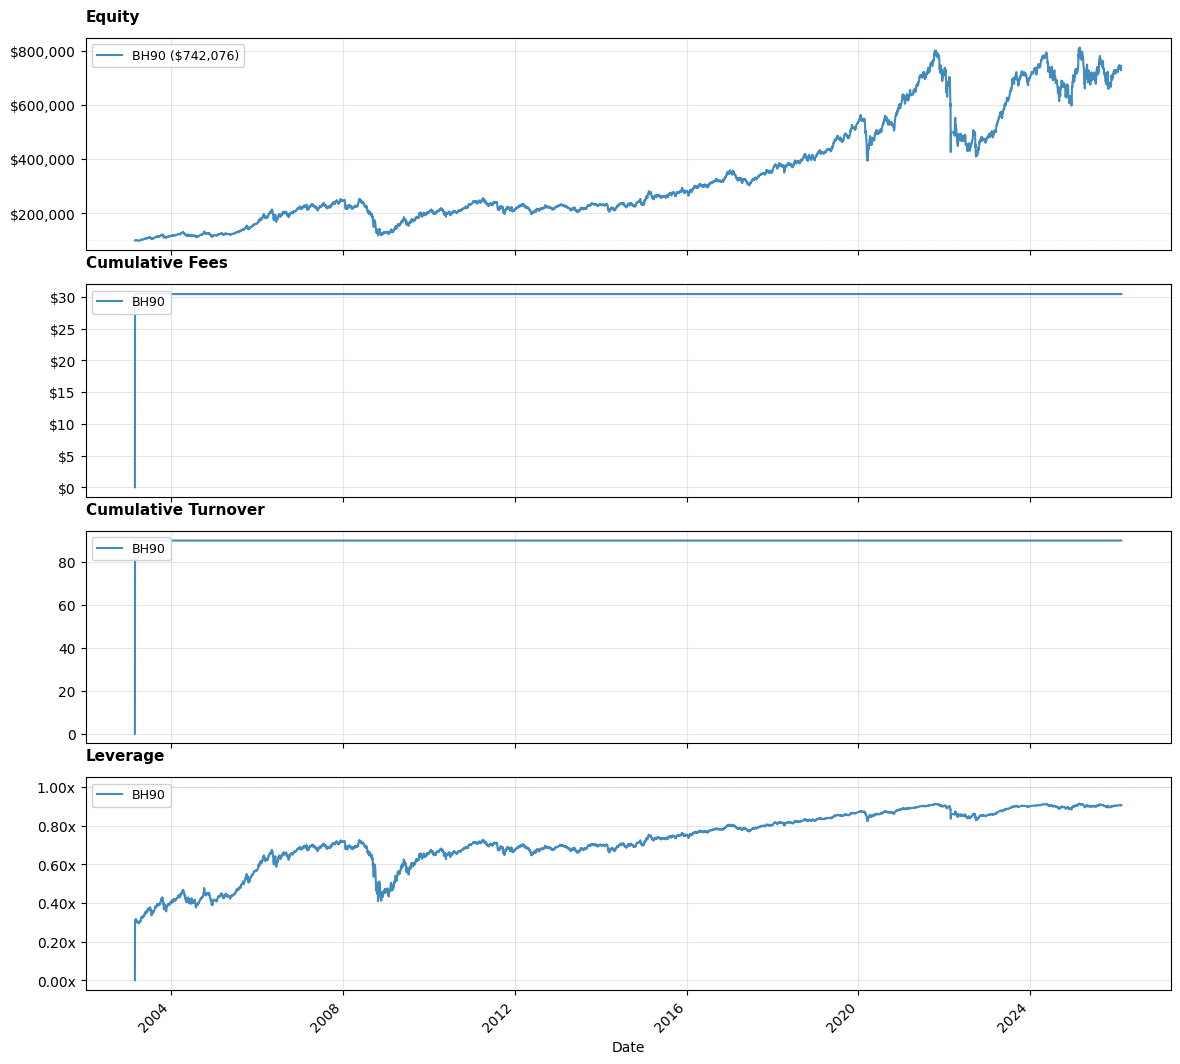

In [20]:
plot_backtest_results(
    results={"BH90": bh_result},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

In [37]:
strategy_fixed = FixedRiskPositionStrategy(volatility_window=21, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)


In [38]:
strategy_fixed_result = engine.run(strategy_fixed, data)

In [39]:
strategy_fixed_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +6.7% │
│ Average drawdown                         │                    -1.4% │
│ Maximum drawdown                         │                   -17.6% │
│ Annualised standard deviation            │                     7.8% │
│ Sharpe ratio                             │                     0.86 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     1.96 │
│ Upper tail                               │                     1.86 │
└──────────────────────────────────────────────────────────────────────┘


c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


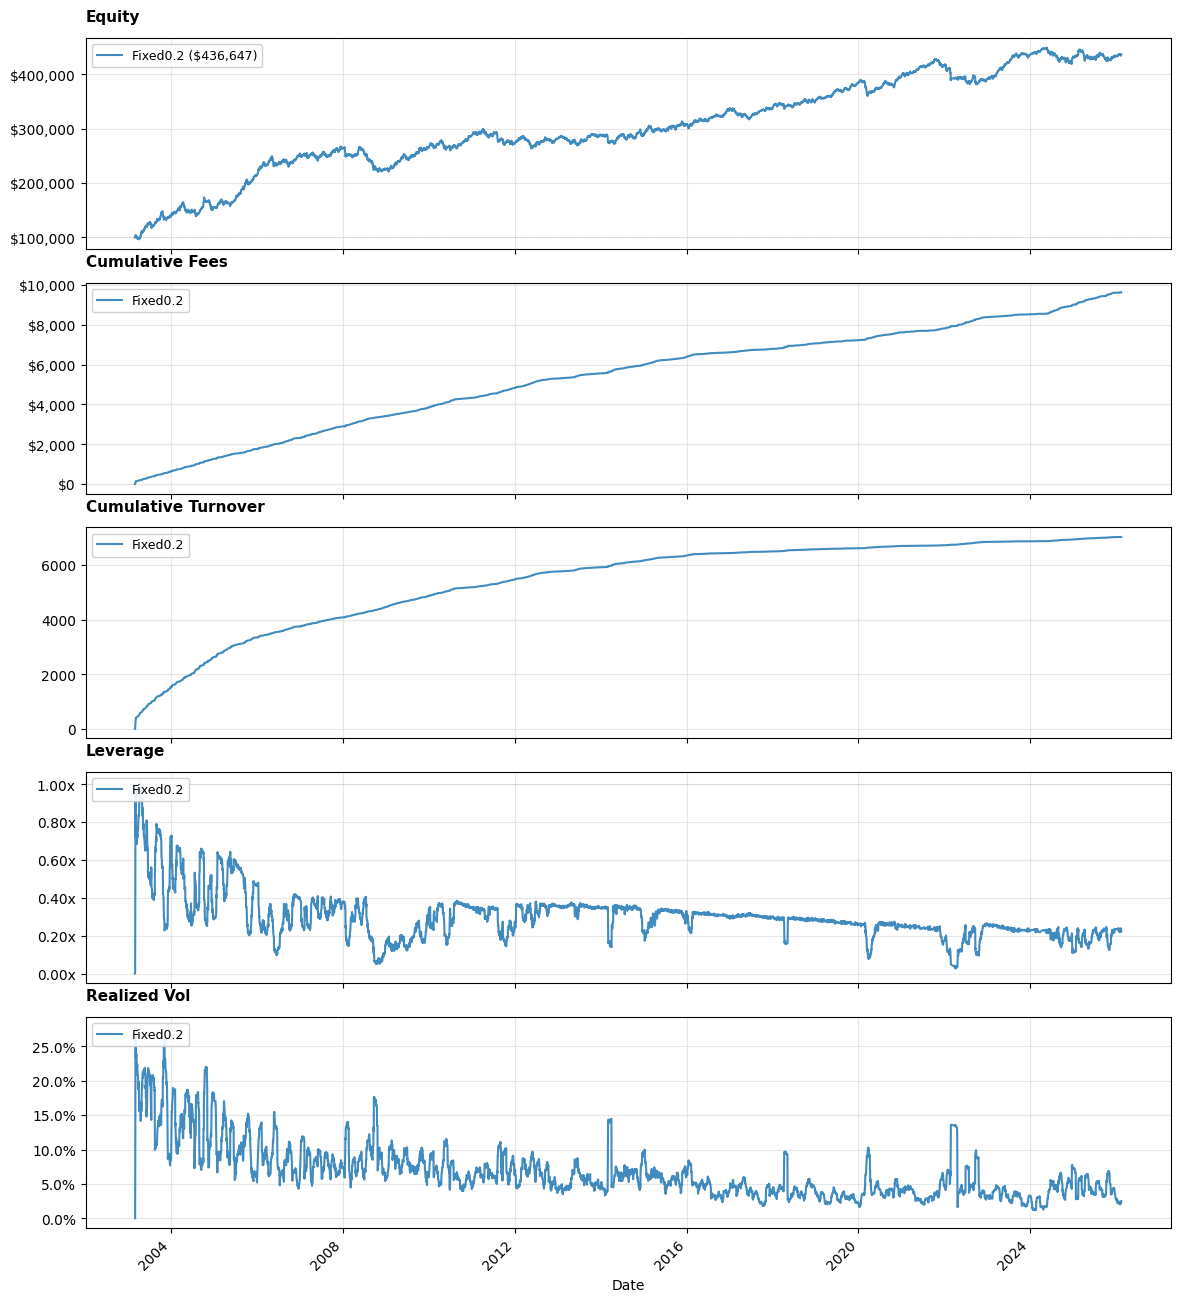

In [40]:
plot_backtest_results(
    results={"Fixed0.2": strategy_fixed_result},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage', 'realized_vol'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

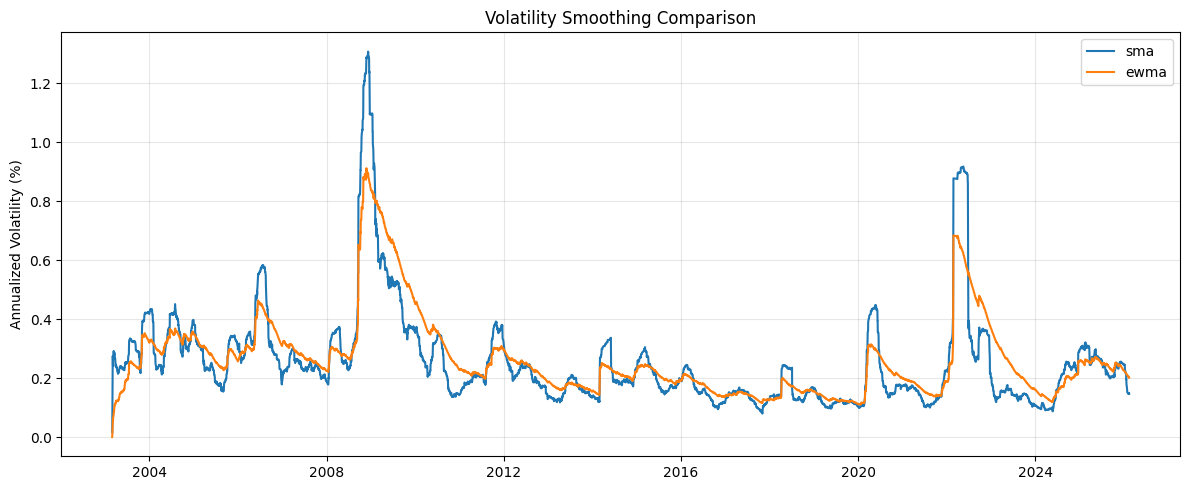

In [46]:
methods = ['sma', 'ewma']
fig, ax = plt.subplots(figsize=(12, 5))

for m in methods:
    strat = FixedRiskPositionStrategy(vol_method=m, lambda_param=0.99, volatility_window=63)
    vol = strat.calculate_volatility(data)
    ax.plot(vol.index, vol, label=f"{m}", linewidth=1.5)

ax.set_title("Volatility Smoothing Comparison")
ax.set_ylabel("Annualized Volatility (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
strategy_ewma = FixedRiskPositionStrategy(vol_method='ewma', lambda_param=0.968, max_leverage=MAX_LEVERAGE)
strategy_ewma_result = engine.run(strategy_ewma, data)
strategy_f = FixedRiskPositionStrategy(vol_method='sma', volatility_window=63, max_leverage=MAX_LEVERAGE)
strategy_f_result = engine.run(strategy_f, data)

In [65]:
from sysstrat import print_comparison_table
print_comparison_table({"Fixed": strategy_f_result, "EWMA": strategy_ewma_result})

┌──────────────────────────────────────────────┐
│              Strategy Comparison               │
├──────────────────────┼───────────┼───────────┤
│ Metric               │ Fixed     │ EWMA      │
├──────────────────────┼───────────┼───────────┤
│ 📈 Returns & Performance │                        │
│ Total Return %       │ +301.62%  │ +314.49%  │
│ CAGR %               │ +6.30%    │ +6.44%    │
│ Gross Return %       │ +307.77%  │ +320.94%  │
├──────────────────────┼───────────┼───────────┤
│ ⚠️ Risk & Volatility │                        │
│ Annual Vol %         │ +8.74%    │ +8.26%    │
│ Max Drawdown %       │ -22.95%   │ -20.59%   │
│ Avg Drawdown %       │ -1.59%    │ -1.53%    │
├──────────────────────┼───────────┼───────────┤
│ 🎯 Risk-Adjusted Returns │                        │
│ Sharpe Ratio         │ 0.72      │ 0.78      │
│ Gross Sharpe         │ 0.73      │ 0.79      │
│ Turnover-Adj Sharpe  │ 0.65      │ 0.70      │
│ Sharpe Drag          │ 0.01      │ 0.01      │
├────────

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


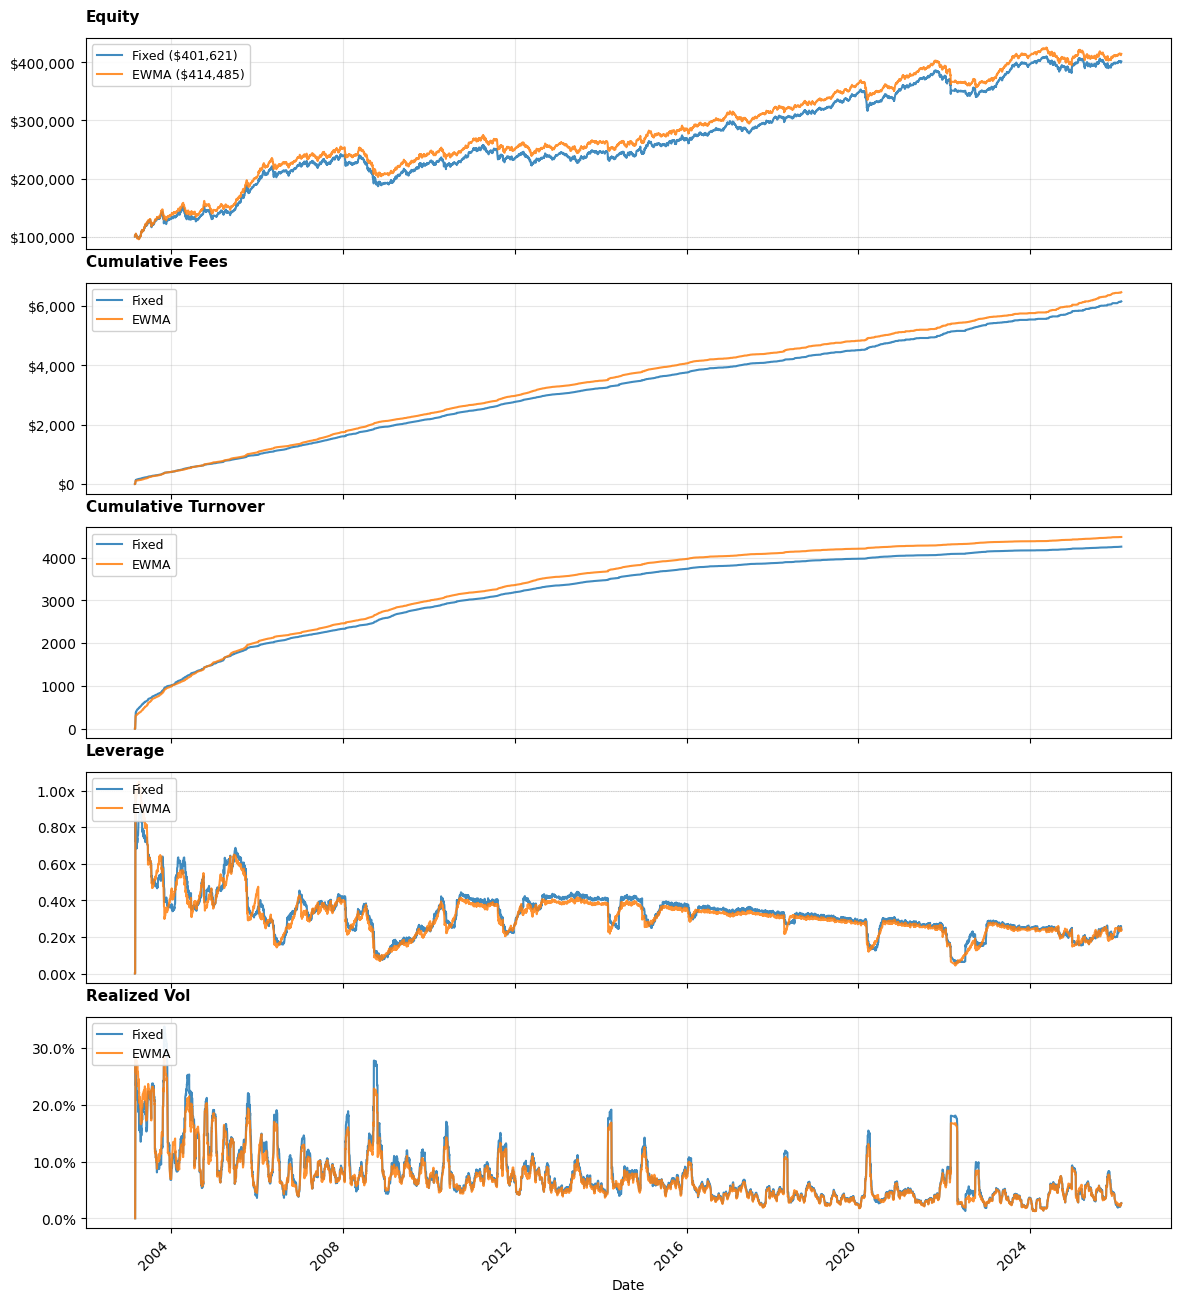

In [66]:
plot_backtest_results(
    results={"Fixed": strategy_f_result, "EWMA": strategy_ewma_result},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage',"realized_vol"],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)